In [1]:
import pandas as pd
from Bio import SeqIO
import sys
import os
from ast import literal_eval
import numpy as np

import pybedtools
from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/Collaboration/backup/MPRA_QC_pipeline/QC_analysis/scripts')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
const.set_plot_style()
import matplotlib.ticker as mtick

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/'

/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


# 1. Load original libraries

In [2]:
library = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = 'oligos',
                    usecols=lambda x: x not in ["derived_seq_with_adapters", "ancestral_seq_with_adapters"],
                     header=0)

# 2. Filter libraries to not include hh oligos

In [3]:
print(f'rows before filtering for SCREEN: {len(library)}')
library = library[library['source'].str.contains('SCREEN')]
print(f'rows after filtering for SCREEN: {len(library)}')
print(f'oligo counts after filtering for SCREEN: {len(library)*2}')


rows before filtering for SCREEN: 355697
rows after filtering for SCREEN: 343503
oligo counts after filtering for SCREEN: 687006


# 3. Read L4 library

In [4]:
library_L4 = pd.read_excel(
    "/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx",
    sheet_name="test_oligos",
    usecols=lambda x: x not in ["derived_sequence_with_adapters", "ancestral_seq_with_adapters"],
    header=0
)

#change colnames to match library
library_L4 = library_L4.rename(columns={
    'name_derived_sequence': 'name_ancestral',
    'name_ancestral_sequence': 'name_derived'})


# 4. Filter L4 to only include relevant oligos 

In [5]:
library_L4_filtered = library_L4.copy()
library_L4_filtered = library_L4_filtered[(library_L4_filtered['adapter']=='a1')&
                                          (library_L4_filtered['name'].str.contains('SCREEN'))&
                                          (library_L4_filtered['class'].isin(['CGI.fix','promoter.orientation.fix']))]
print(f'oligo counts in L4: {len(library_L4_filtered)*2}')

oligo counts in L4: 51740


# 3. Filter oligos from original libraries that were fixed in L4a1.

In [6]:
fixed_variants = library_L4_filtered['variants_genomic']
fixed_oligos = sum(library['variants_genomic'].isin(fixed_variants))
print(f'oligos fixed in L4a1 which I removed from the original library design:{fixed_oligos}')

filtered_library = library[~library['variants_genomic'].isin(fixed_variants)]


oligos fixed in L4a1 which I removed from the original library design:2971


# 4. merge L4 with the rest of the libraries and remove duplicates

In [7]:
# columns shared by both
common_cols = filtered_library.columns.intersection(library_L4_filtered.columns)

# concatenate, keeping only shared columns (aligned + same order)
final_oligos = pd.concat([library_L4_filtered[common_cols],filtered_library[common_cols]], ignore_index=True)

final_oligos = final_oligos.drop_duplicates(
    subset="variants_genomic",
    keep="first"
)

In [ ]:
all_variants = (
    final_oligos["variants_genomic"]
      .dropna()
      .str.split(";")
      .explode()
      .tolist()
)
len(set(all_variants))


561410

# Error: Change the number of variants to unique!!!!! 

In [ ]:
oligo_pairs_count = len(final_oligos)
oligos_count = oligo_pairs_count*2
variants_count = sum(final_oligos['variants_count'])

print(f'final number of oligo pairs: {oligo_pairs_count}')
print(f'final number of oligos: {oligos_count}')
print(f'final number of variants: {variants_count}')


final number of oligo pairs: 366402
final number of oligos: 732804
final number of variants: 574290.0


# Produce number of active oligos in the entire hMPRA

In [11]:
annotations = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     header=0)
annotations = annotations.drop_duplicates(subset=["oligo"], keep = "first") #There are several HH oligos which are duplicated
annotations = annotations[#~(annotations['orientation_fix']=='fixed_in_L4')&
                           ~(annotations['oligo'].str.contains('SCREEN_EH'))&
                          ~(annotations['oligo'].str.contains('hh.missing.oligos')) ]


# create BED of annotations
annotations_bed_df = annotations[["chromosome","start","end","oligo"]]
annotations_bed_df.loc[:,"start"] = annotations_bed_df["start"].map(int) # already zero-based - Make sure with Simon!!
annotations_bed_df.loc[:,"end"] = annotations_bed_df["end"].map(int)
annotations_bed_df=annotations_bed_df.sort_values(['chromosome','start'], ascending = [True, True])
annotations_bed = pybedtools.BedTool.from_dataframe(annotations_bed_df)

/tmp/ipykernel_3265591/685824466.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


# Number of sequences showing significant activity

In [ ]:
active_oligos_df = annotations.copy()
#active_oligos_count  = sum(active_oligos_df['activity_ancestral']=='active')+sum(active_oligos_df['activity_derived']=='active')
active_sequence_pair_counts = sum(~active_oligos_df['differential_activity'].isna())

print(f'Number of active sequences in the hMPRA:{active_sequence_pair_counts}')

print(f'percentage of active sequences in the hMPRA:{100*(active_sequence_pair_counts/oligo_pairs_count)}%')

Number of active sequences in the hMPRA:65576


NameError: name 'oligo_pairs_count' is not defined

# The number of observed differentially active oligos

In [ ]:
diff_active_oligos = annotations.copy()
diff_active_oligos = diff_active_oligos[diff_active_oligos['differential_activity']==True]
diff_active_oligos_count = len(diff_active_oligos)
print(f'Number of diff active oligos: {diff_active_oligos_count}')
print(f'Number of variants in diff active oligos: {sum(diff_active_oligos['variants_count'])}')
print(f'% of diff active oligo pairs out of all active oligo paris: {100*(diff_active_oligos_count/active_sequence_pair_counts)}')


Number of diff active oligos: 15077
Number of variants in diff active oligos: 25800.0
% of diff active oligo pairs out of all active oligo paris: 22.99164328412834


# The number of positive controls in all libraries combined

In [ ]:
active_controls_chonds_ost = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = 'ctrl_active_chondr',
                     header=0)

active_controls_ESCs_Osteoblasts_NPCs = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = "ctrl_active_not_diff",
                     header=0)
active_controls_chonds_ost_L4 = pd.read_excel(
    "/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx",
    sheet_name="ctrl_Pos_active_chondr",
    header=0)
active_controls_ESCs_Osteoblasts_NPCs_L4 = pd.read_excel(
    "/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx",
    sheet_name="ctrl_Neg_diff",
    header=0)

In [ ]:
active_controls_count = len(active_controls_chonds_ost)+len(active_controls_ESCs_Osteoblasts_NPCs)+len(active_controls_chonds_ost_L4)+len(active_controls_ESCs_Osteoblasts_NPCs_L4)

print(f'Number of active controls in the library: {active_controls_count}')

Number of active controls in the library: 1527


# The number of negative controls in all libraries combined

In [ ]:
scrambled_control = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = 'ctrl_scrambled',
                     header=0)
NegCtrl_non_SCREEN = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = 'ctrl_non_SCREEN',
                     header=0)
NegCtrl_not_active_ESCs_Osteoblasts_NPCs = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = 'ctrl_not_active',
                     header=0)

scrambled_control_L4 = pd.read_excel(
    "/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx", 
    sheet_name = "ctrl_scrambled",
    header=0)

# Note: there is no non-SCREEN controls in L4a1

NegCtrl_not_active_ESCs_Osteoblasts_NPCs_L4 = pd.read_excel(
    "/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx",
    sheet_name="ctrl_Neg_active",
    header=0)

In [ ]:
neg_controls_count = len(scrambled_control)+len(NegCtrl_non_SCREEN)+len(NegCtrl_not_active_ESCs_Osteoblasts_NPCs)+len(scrambled_control_L4)+len(NegCtrl_not_active_ESCs_Osteoblasts_NPCs_L4)

print(f'Number of negative controls for activity in the library: {neg_controls_count}')

Number of negative controls for activity in the library: 3436


# Number of differentially active controls

In [ ]:
diff_activity_ctrls = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = 'ctrl_diff_active',
                     header=0)

diff_activity_ctrls_L4 = pd.read_excel("/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx", 
    sheet_name = "ctrl_Pos_diff",
    header=0)


In [ ]:
diff_activity_ctrls

,chromosome,start,end,cell,cell_count,library,adapter,internal_ID,derived_sequence,ancestral_seq,ancestral_sequence_with_adapters,derived_sequence_with_adapters,name_ancestral,name_derived,Weiss_et_al_MPRA_seq_ID
0,chrX,70401788,70402057,ESCs+Osteoblasts+NPCs,3,L1,a1,1,gctggcagttcctgttgttctcagctagtatttcgttttagtcccc...,gctggcagttcctgttgttctcagctagtatttcgTTTTAGTCCCC...,AGGACCGGATCAACTgctggcagttcctgttgttctcagctagtat...,AGGACCGGATCAACTgctggcagttcctgttgttctcagctagtat...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq24...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq24...,libA_seq24683_[chrX:70401823-70402022]
1,chr7,4786735,4787004,ESCs+Osteoblasts+NPCs,3,L1,a1,2,tccgaatctgttgaaaggacatccccacgcccgcgtttcctgtaat...,tccgaatctgttgaaaggacatccccacgcccgcgTTTCCTGTAAT...,AGGACCGGATCAACTtccgaatctgttgaaaggacatccccacgcc...,AGGACCGGATCAACTtccgaatctgttgaaaggacatccccacgcc...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq13...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq13...,libB_seq136029_[chr7:4786770-4786969]
2,chr3,38063356,38063625,ESCs+Osteoblasts+NPCs,3,L1,a1,3,tcccattttatccataccccctcccccagccagcctgtcccacata...,tcccattttatccataccccctcccccagccagccTGTCCCACATA...,AGGACCGGATCAACTtcccattttatccataccccctcccccagcc...,AGGACCGGATCAACTtcccattttatccataccccctcccccagcc...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq96...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq96...,libB_seq96982_[chr3:38063391-38063590]
3,chr17,699826,700095,ESCs+Osteoblasts+NPCs,3,L1,a1,4,cttgtctttaaaaaaaaaaaaaagaaatgcaggaagggaacaggga...,cttgtctttaaaaaaaaaaaaaagaaatgcaggaaGGGAACAGGGA...,AGGACCGGATCAACTcttgtctttaaaaaaaaaaaaaagaaatgca...,AGGACCGGATCAACTcttgtctttaaaaaaaaaaaaaagaaatgca...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq91...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq91...,libA_seq91171_[chr17:699861-700060]
4,chr2,85889505,85889774,ESCs+Osteoblasts+NPCs,3,L1,a1,5,catttcagttctagaaggaaacttaacgttcatctggtccttgaga...,catttcagttctagaaggaaacttaacgttcatctGGTCCTTGAGA...,AGGACCGGATCAACTcatttcagttctagaaggaaacttaacgttc...,AGGACCGGATCAACTcatttcagttctagaaggaaacttaacgttc...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq22...,PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq22...,libB_seq225886_[chr2:85889540-85889739]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,chr15,100597302,100597571,ESCs,1,L3,a3,1203,ggccaggactgctaagatcagttctgggcggggtgatggagggagg...,ggccaggactgctaagatcagttctgggcggggtgATGGAGGGAGG...,TTACGAGCCGTAGTCggccaggactgctaagatcagttctgggcgg...,TTACGAGCCGTAGTCggccaggactgctaagatcagttctgggcgg...,PosCtrl_diff_ESCs_Weiss_seq259341_ancestral_a3_L3,PosCtrl_diff_ESCs_Weiss_seq259341_derived_a3_L3,libB_seq259341_[chr15:100597337-100597536]
1203,chr7,92891343,92891612,Osteoblasts,1,L3,a3,1204,gaattaagaagaggaaacctcaatattggaaaattggtaggagaga...,gaattaagaagaggaaacctcaatattggaaaattGGTAGGAGAGA...,TTACGAGCCGTAGTCgaattaagaagaggaaacctcaatattggaa...,TTACGAGCCGTAGTCgaattaagaagaggaaacctcaatattggaa...,PosCtrl_diff_Osteoblasts_Weiss_seq197855_ances...,PosCtrl_diff_Osteoblasts_Weiss_seq197855_deriv...,libB_seq197855_[chr7:92891378-92891577]
1204,chr8,33010421,33010690,NPCs,1,L3,a3,1205,tctgtgtgggagagactaactgattattcatcaaacctaactcatc...,tctgtgtgggagagactaactgattattcatcaaaCCTAACTCATC...,TTACGAGCCGTAGTCtctgtgtgggagagactaactgattattcat...,TTACGAGCCGTAGTCtctgtgtgggagagactaactgattattcat...,PosCtrl_diff_NPCs_Weiss_seq240980_ancestral_a3_L3,PosCtrl_diff_NPCs_Weiss_seq240980_derived_a3_L3,libA_seq240980_[chr8:33010456-33010655]
1205,chrX,6904919,6905188,Osteoblasts,1,L3,a3,1206,ctgcatccgaatatccccaaagcagaatttcattgccaatctcaga...,ctgcatccgaatatccccaaagcagaatttcattgCCAATCTCAGA...,TTACGAGCCGTAGTCctgcatccgaatatccccaaagcagaatttc...,TTACGAGCCGTAGTCctgcatccgaatatccccaaagcagaatttc...,PosCtrl_diff_Osteoblasts_Weiss_seq100031_ances...,PosCtrl_diff_Osteoblasts_Weiss_seq100031_deriv...,libA_seq100031_[chrX:6904954-6905153]


In [ ]:
diff_activity_ctrls_count = len(diff_activity_ctrls)+len(diff_activity_ctrls_L4)

print(f'Number of controls for differential activity in the library: {diff_activity_ctrls_count}')

Number of controls for differential activity in the library: 1329


# Total number of oligos in the library

In [ ]:
full_oligo_counts = diff_activity_ctrls_count+neg_controls_count+active_controls_count+oligos_count
print(f'Number of oligos in the library (+controls): {full_oligo_counts}')

Number of oligos in the library (+controls): 739096


# Top candidates information

In [ ]:
EVC = annotations[annotations['oligo']=='seq_9777_chr4:5774930-5775199_Hh+SCREEN_a3_L3']

## Find name of CSGALNACT1 eQTL

In [ ]:

R2Gtool = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/region_gene_link/chondrocytes/yardens_script/output_Nadav2_16-12-2024/Summary_PerEvidence.tsv', 
                     header=0,sep = '\t')

/tmp/ipykernel_2015929/112010412.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  R2Gtool = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/region_gene_link/chondrocytes/yardens_script/output_Nadav2_16-12-2024/Summary_PerEvidence.tsv',


In [ ]:
R2Gtool[(R2Gtool['Gene_symbol']=='CSGALNACT1')&(R2Gtool['Distance_to_gene(TSS)']==3960)]

,chromosome,start,end,region_id,NCBI_Gene_ID,Gene_symbol,Distance_to_gene(TSS),closest_gene,within_promoter,eRNA_pval,eQTL_id,eQTL_beta,eQTL_pval,eQTL_element_distance,eQTL_Tissue,HiC_P-O_pval,HiC_element_distance,HiC_Tissue
2110702,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19537084_A_G_b37,0.282312,8.158640e-10,931.0,Heart_Left_Ventricle,NaN,NaN,NaN
2110703,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19536798_T_A_b37,0.221493,5.890910e-08,645.0,Heart_Left_Ventricle,NaN,NaN,NaN
2110705,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19535491_G_A_b37,0.308673,8.806620e-10,-393.0,Thyroid,NaN,NaN,NaN
2110706,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19535997_C_T_b37,-0.318026,2.923610e-07,0.0,Heart_Left_Ventricle,NaN,NaN,NaN
2110707,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,0.024094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2110708,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19535115_G_T_b37,-0.302565,1.930670e-07,-769.0,Whole_Blood,NaN,NaN,NaN
2110709,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19535491_G_A_b37,0.169624,3.622520e-06,-393.0,Whole_Blood,NaN,NaN,NaN
2110710,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19535849_G_A_b37,-0.278611,2.226050e-07,-35.0,Whole_Blood,NaN,NaN,NaN
2110711,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19535997_C_T_b37,-0.302565,1.930670e-07,0.0,Whole_Blood,NaN,NaN,NaN
2110712,chr8,19535883,19536153,113545,55790.0,CSGALNACT1,3960.0,True,False,NaN,8_19536015_A_G_b37,0.169204,3.852390e-06,0.0,Whole_Blood,NaN,NaN,NaN


## Find expression LFC of CSGALNACT1

In [ ]:

G_hybrids = pd.read_csv(f'/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Hybrids/human_gorilla/ExpLBM/outputs_5Jan2026_for_hMPRA_draft1/ASE/combined_lfc_with_ASE_definition.tsv', 
                     header=0,sep = '\t')

C_hybrids = pd.read_csv(f"/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Hybrids/human_chimp/ExpLBM/outputs_05Jan2026_humanMPRA_draft1/ExpLBM_polarization_results.tsv", 
                     sep = '\t',
                     header=0)

In [ ]:
C_hybrids

,Gene,ExpLBM_TPM_human_allele,ExpLBM_TPM_chimp_allele,ExpLBM_TPM_gorilla_allele,ExpLBM_TPM_total,ExpLBM_log2TPM_human_allele,ExpLBM_log2TPM_chimp_allele,ExpLBM_log2TPM_gorilla_allele,ExpLBM_log2TPM_total,ExpLBM_LFC_human_ref,ExpLBM_LFC_padj_human_ref,ExpLBM_LFC_chimp_ref,ExpLBM_LFC_padj_chimp_ref,ExpLBM_gene_ase_type,d_GH,d_GC,human_derived_score,derived
0,A1BG,0.589528,0.527905,1.412338,2.210705,0.668598,0.611555,1.270432,1.682890,0.230332,0.394157,0.268019,0.307232,nonASE,0.601834,0.658877,-1.000000,chimp-derived
1,A2M,1.409486,1.120505,1.318553,4.860193,1.268725,1.084408,1.213224,2.550948,0.351554,0.011117,0.278937,0.053456,nonASE,0.055501,0.128817,-0.370662,chimp-derived
2,A2MP1,0.011313,0.016085,0.006907,0.036106,0.016230,0.023021,0.009931,0.051171,-0.124703,0.848341,0.205740,0.684719,else,0.006299,0.013090,-1.000000,chimp-derived
3,NAT1,2.001059,1.603822,1.688204,3.989507,1.585472,1.380631,1.426642,2.318897,0.341566,0.014630,0.434379,0.001459,ASE,0.158829,0.046012,0.575156,human-derived
4,NAT2,0.573581,0.655862,0.828586,1.762164,0.654052,0.727582,0.870728,1.465799,-0.157079,0.687675,0.080235,0.856452,else,0.216677,0.143146,1.000000,human-derived
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92614,bP-2189O9.5,0.010645,0.008531,0.000000,0.045655,0.015276,0.012255,0.000000,0.064407,-0.005127,NaN,NaN,NaN,else,0.015276,0.012255,1.000000,human-derived
92615,hsa-mir-1253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,else,0.000000,0.000000,NaN,NaN
92616,hsa-mir-423,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,else,0.000000,0.000000,NaN,NaN
92617,snoZ196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,else,0.000000,0.000000,NaN,NaN


In [ ]:
CGAT1_G_hybrids = G_hybrids[G_hybrids['Gene']=='CSGALNACT1']
CGAT1_C_hybrids = C_hybrids[C_hybrids['Gene']=='CSGALNACT1']

In [ ]:
CGAT1_G_hybrids

,Gene,log2FoldChange_human_ref,pvalue_human_ref,padj_human_ref,padj_mine_human_ref,qval_mine_human_ref,mean_ref_tpm_human_ref,mean_alt_tpm_human_ref,mean_total_tpm_human_ref,log2FoldChange_gorilla_ref,pvalue_gorilla_ref,padj_gorilla_ref,padj_mine_gorilla_ref,qval_mine_gorilla_ref,mean_ref_tpm_gorilla_ref,mean_alt_tpm_gorilla_ref,mean_total_tpm_gorilla_ref,ASE_definition
7696,CSGALNACT1,-0.605798,0.006164,0.01236,0.016698,0.010628,0.738789,1.142487,2.16791,-0.478287,0.03466,0.055944,0.063145,0.028897,0.799269,1.098725,2.187042,nonASE


In [ ]:
CGAT1_C_hybrids

,Gene,ExpLBM_TPM_human_allele,ExpLBM_TPM_chimp_allele,ExpLBM_TPM_gorilla_allele,ExpLBM_TPM_total,ExpLBM_log2TPM_human_allele,ExpLBM_log2TPM_chimp_allele,ExpLBM_log2TPM_gorilla_allele,ExpLBM_log2TPM_total,ExpLBM_LFC_human_ref,ExpLBM_LFC_padj_human_ref,ExpLBM_LFC_chimp_ref,ExpLBM_LFC_padj_chimp_ref,ExpLBM_gene_ase_type,d_GH,d_GC,human_derived_score,derived
12385,CSGALNACT1,0.327024,0.600101,1.142487,1.314668,0.408195,0.678163,1.099286,1.210805,-0.774254,0.000239,-0.646021,0.003265,ASE,0.691092,0.421123,1.0,human-derived


In [ ]:
import math

log2fc_value = -0.77425380391077
fold_change = 2**log2fc_value
percent_change = (fold_change - 1) * 100
print(f"{fold_change=}")
print(f"{percent_change=}")

fold_change=0.584690962117517
percent_change=-41.530903788248295


In [ ]:
log2fc_value = -0.605798079693457
fold_change = 2**log2fc_value
percent_change = (fold_change - 1) * 100
print(f"{fold_change=}")
print(f"{percent_change=}")



fold_change=0.6571077762660869
percent_change=-34.28922237339131


# Create combined library design table (+L4)

In [17]:
L123_library_design = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx',
sheet_name='oligos')

L4_library_design = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx',
sheet_name='test_oligos')

In [18]:
L4_library_design_filtered = L4_library_design[(L4_library_design['adapter']=='a1')&(L4_library_design['library']==('L4'))&(L4_library_design['class'].isin(['CGI.fix','promoter.orientation.fix']))&(L4_library_design['source'].str.contains('SCREEN'))]

In [19]:
# Find rows in L123 that match L4 in chr, start, end
L123_L4_matches = L123_library_design.merge(
    L4_library_design_filtered[['chr', 'start', 'end']],
    on=['chr', 'start', 'end'],
    how='inner'
)

rows_removed = len(L123_L4_matches)

# Filter L123 to remove matching rows
L123_filtered = L123_library_design[
    ~L123_library_design.set_index(['chr', 'start', 'end']).index.isin(
        L4_library_design_filtered.set_index(['chr', 'start', 'end']).index
    )
].reset_index(drop=True)

print(f'Number of rows removed from L123: {rows_removed}')

Number of rows removed from L123: 2971


In [20]:
# Merge the filtered L4 and L123 datasets, keeping only shared columns (aligned + same order)
common_cols = L123_filtered.columns.intersection(L4_library_design_filtered.columns)
combined_library_design = pd.concat(
    [L4_library_design_filtered[common_cols], L123_filtered[common_cols]],
    ignore_index=True
)
combined_library_design = combined_library_design.drop_duplicates(keep="first")

#remove hedgehog only
combined_library_design = combined_library_design[combined_library_design['source'].str.contains('SCREEN')]


In [21]:
all_variants = (
    combined_library_design["variants_genomic"]
      .dropna()
      .str.split(";")
      .explode()
      .tolist()
)
len(set(all_variants))

561410

In [22]:
# Create a publication-friendly version of the combined library design columns
publish_cols = {
    "chr": "Chromosome",
    "start": "Start",
    "end": "End",
    "variants_count": "Variants count",
    "variants_genomic": "Variants (genomic)",
    "variants_tile": "Variants (tile)",
    "adapter": "Adapter",
    "library": "Library",
    "ID": "ID",
    "source": "Source",
}

combined_library_design_pub = combined_library_design.rename(columns=publish_cols)

In [ ]:
len(combined_library_design_pub)*2


732804

In [106]:
combined_library_design_pub.to_excel(f'/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/combined_library_design.xlsx', index=False)

# Compare library design to final oligo output

In [3]:
library_design = pd.read_excel('/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/combined_library_design.xlsx')

In [4]:
final_output = pd.read_csv("/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv")

/tmp/ipykernel_3265591/949665625.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  final_output = pd.read_csv("/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv")


In [5]:
final_output_oligos_id = final_output["oligo"].str.extract(r"^seq_(\d+)_", expand=False)
final_output_oligos_id = pd.to_numeric(final_output_oligos_id, errors="coerce").astype("Int64")


In [6]:
library_design_oligos_id = library_design["ID"].astype("int64")


In [7]:
missing_in_output = library_design_oligos_id[~library_design_oligos_id.isin(final_output_oligos_id)]

In [8]:
# Make sure both sides are int
ids = pd.to_numeric(library_design["ID"], errors="coerce").astype("Int64")
missing = pd.to_numeric(missing_in_output, errors="coerce").astype("Int64")

missing_oligos = library_design[ids.isin(missing)]
detected_oligos = library_design[~ids.isin(missing)]

In [9]:
detected_oligos_L4a1 = detected_oligos[(detected_oligos['Library']=='L4') & (detected_oligos['Adapter']=='a1')]
missing_oligos_L4a1 = missing_oligos[(missing_oligos['Library']=='L4') & (missing_oligos['Adapter']=='a1')]


In [10]:
missing_oligos_L4a1

,Chromosome,Start,End,Variants count,Variants (genomic),Variants (tile),Adapter,Library,ID
53,chr1,1335301,1335570,1,chr1:1335436(C->A),136(C->A),a1,L4,355751
108,chr1,2477441,2477710,1,chr1:2477576(G->T),136(G->T),a1,L4,355806
111,chr1,2517853,2518122,2,chr1:2517980(C->G);chr1:2517995(G->A),128(C->G);143(G->A),a1,L4,355809
253,chr1,11714631,11714900,1,chr1:11714766(C->A),136(C->A),a1,L4,355951
367,chr1,23670522,23670791,1,chr1:23670657(G->C),136(G->C),a1,L4,356065
...,...,...,...,...,...,...,...,...,...
25529,chr6,27173960,27174229,2,chr6:27174095(C->G);chr6:27174177(G->C),136(C->G);218(G->C),a1,L4,382676
25714,chr17,46651529,46651798,2,chr17:46651652(A->C);chr17:46651664(G->A),124(A->C);136(G->A),a1,L4,382950
25731,chr19,10490735,10491004,2,chr19:10490831(G->C);chr19:10490870(T->C),97(G->C);136(T->C),a1,L4,382973
25775,chr3,15563291,15563560,3,chr3:15563412(A->G);chr3:15563418(T->G);chr3:1...,122(A->G);128(T->G);150(A->T),a1,L4,383046


In [ ]:
# search for missing L4 a1 oligos in the barcode association file
csv_path = "/home/labs/davidgo/Collaboration/humanMPRA/neurons/L4a1/output/DNA_barcode_associations_2/Omer_re-send/final_df.csv"

# read (no header expected based on example rows)
cols = ["barcode_id", "barcode_seq", "oligo", "count"]
assoc = pd.read_csv(csv_path, header=None, names=cols, dtype=str)

# extract numeric oligo ID from the oligo string like "seq_255337_..."
assoc["oligo_id"] = assoc["oligo"].str.extract(r"^seq_(\d+)_", expand=False).astype("Int64")

# prepare list of missing IDs (Int64)
missing_ids = missing_oligos_L4a1["ID"].astype("Int64").unique()

# filter associations for missing IDs and aggregate per oligo
matches = assoc[assoc["oligo_id"].isin(missing_ids)].copy()
agg = (
    matches.groupby("oligo_id")
    .agg(
        n_rows=("oligo", "size"),
        n_unique_barcodes=("barcode_seq", "nunique"),
        barcodes=("barcode_seq", lambda x: ";".join(x.unique()))
    )
    .reset_index()
    .rename(columns={"oligo_id": "ID"})
)

# ensure all missing IDs are present in the output
out = pd.DataFrame({"ID": pd.Series(missing_ids, dtype="Int64")}).merge(agg, on="ID", how="left")
out[["n_rows", "n_unique_barcodes"]] = out[["n_rows", "n_unique_barcodes"]].fillna(0).astype(int)
out["barcodes"] = out["barcodes"].fillna("")

# save results and show a brief summary
out.to_csv("/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/missing_L4a1_barcode_hits.csv", index=False)
print(f"Missing IDs checked: {len(out)}; IDs with >=1 hit: {int((out['n_rows']>0).sum())}")

(array([ 419.,  406.,  394., 1931., 3806., 3787., 3803., 3782., 3801.,
        3795., 3800., 3797., 3794., 3803., 3796., 3802., 3800., 3799.,
        3800., 3804., 3792., 3797., 3803., 3795., 3789., 3790., 3806.,
        3799., 3807., 3795., 3810., 3804., 3804., 3799., 3796., 3801.,
        3797., 3806., 3793., 3795., 3798., 3794., 3805., 3796., 3797.,
        3794., 3801., 3793., 3811., 3792., 3812., 3794., 3797., 3803.,
        3800., 3802., 3791., 3792., 3794., 3803., 3801., 3803., 3800.,
        3803., 3800., 3796., 3797., 3807., 3802., 3796., 3796., 3793.,
        3801., 3800., 3799., 3804., 3796., 3791., 3807., 3807., 3800.,
        3792., 3800., 3784., 3793., 3802., 3797., 3792., 3802., 3791.,
        3794., 3788., 3805., 3809., 3811., 3765., 3814., 3813., 3631.,
        2554.]),
 array([4.8000000e+01, 3.8794200e+03, 7.7108400e+03, 1.1542260e+04,
        1.5373680e+04, 1.9205100e+04, 2.3036520e+04, 2.6867940e+04,
        3.0699360e+04, 3.4530780e+04, 3.8362200e+04, 4.2193620e+04

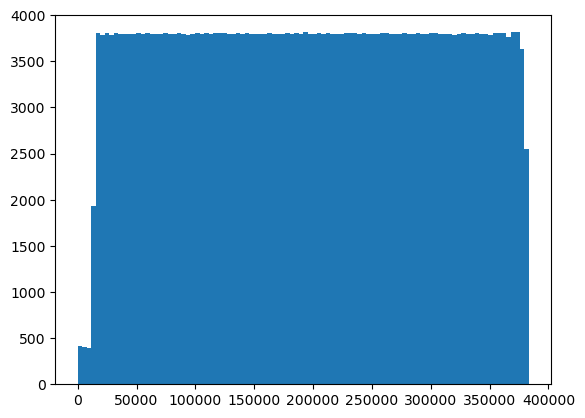

In [64]:
library_design
plt.hist(library_design['ID'],bins=100)

(array([ 21.,  11.,  14.,  41.,  65.,  59.,  61.,  71.,  75.,  60.,  65.,
         57.,  58.,  72.,  71.,  54.,  66.,  55.,  64.,  44.,  65.,  50.,
         50.,  54.,  59.,  64.,  51.,  66.,  54.,  66.,  60.,  78.,  64.,
         50.,  57.,  94.,  78.,  87.,  82.,  78.,  83.,  65.,  92.,  75.,
         85., 130., 116., 134., 138., 114., 134., 133., 136., 122., 130.,
        205., 198., 166., 222., 194., 199., 195., 210., 186., 173., 131.,
        115., 135., 133., 114., 103., 101., 102., 100., 113., 122., 140.,
        170., 128., 142., 140., 163., 161., 148., 150., 144., 201., 207.,
        210., 187., 192., 180., 171.,  77.,  59.,  78.,  55.,  46.,  59.,
         17.]),
 array([1.4100000e+02, 3.9701200e+03, 7.7992400e+03, 1.1628360e+04,
        1.5457480e+04, 1.9286600e+04, 2.3115720e+04, 2.6944840e+04,
        3.0773960e+04, 3.4603080e+04, 3.8432200e+04, 4.2261320e+04,
        4.6090440e+04, 4.9919560e+04, 5.3748680e+04, 5.7577800e+04,
        6.1406920e+04, 6.5236040e+04, 6.906516

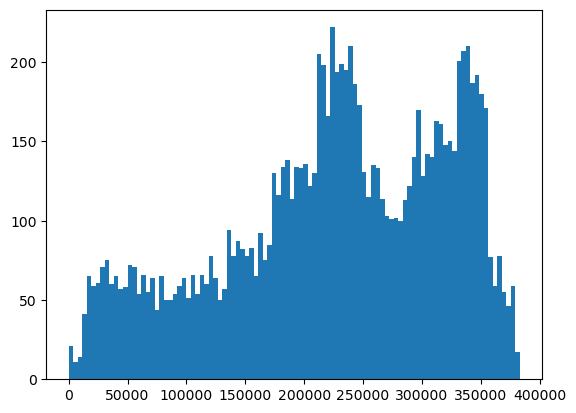

In [63]:
plt.hist(missing_in_library['ID'],bins=100)

In [74]:
print(missing_in_library[missing_in_library['Variants (genomic)']=='chr10:18872538(G->A);chr10:18872581(T->C);chr10:18872697(C->T)'])

       Chromosome     Start       End  Variants count  \
108128      chr10  18872483  18872752               3   

                                       Variants (genomic)  \
108128  chr10:18872538(G->A);chr10:18872581(T->C);chr1...   

                    Variants (tile) Adapter Library      ID  
108128  56(G->A);99(T->C);215(C->T)      a1      L3  264514  


In [75]:
contained_in_library = library_design[~ids.isin(missing)]


In [78]:
contained_in_library[contained_in_library['Library']=='L3']

,Chromosome,Start,End,Variants count,Variants (genomic),Variants (tile),Adapter,Library,ID
104277,chr1,1546459,1546728,3,chr1:1546587(T->G);chr1:1546600(C->T);chr1:154...,129(T->G);142(C->T);244(C->A),a1,L3,255337
104278,chr1,1549012,1549281,1,chr1:1549147(G->A),136(G->A),a1,L3,268550
104279,chr1,1792523,1792792,2,chr1:1792637(T->C);chr1:1792679(G->A),115(T->C);157(G->A),a1,L3,252151
104280,chr1,1946434,1946703,1,chr1:1946569(G->A),136(G->A),a1,L3,274483
104281,chr1,2191288,2191557,2,chr1:2191408(C->T);chr1:2191438(C->T),121(C->T);151(C->T),a1,L3,272244
...,...,...,...,...,...,...,...,...,...
366397,chrX,149958563,149958832,2,chrX:149958665(T->C);chrX:149958730(G->A),103(T->C);168(G->A),a3,L3,341825
366398,chrX,152016687,152016956,2,chrX:152016804(A->G);chrX:152016840(C->T),118(A->G);154(C->T),a3,L3,343953
366399,chrX,153946560,153946829,1,chrX:153946695(A->C),136(A->C),a3,L3,339556
366400,chrX,154245428,154245697,1,chrX:154245563(T->G),136(T->G),a3,L3,330160


## Create Activity supplementary table

In [ ]:
#too heavy to hold everything in memory, so I will delete the dataframes I don't need anymore
del [library, library_L4, library_L4_filtered]


In [46]:
full_activity_df = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv')


/tmp/ipykernel_293893/3656142334.py:1: DtypeWarning: Columns (55) have mixed types. Specify dtype option on import or set low_memory=False.
  full_activity_df = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv')


In [47]:
#remove unnecesary columns to save memory (everything except RNA_chondrocytes_rep1)
full_activity_df = full_activity_df.drop(columns=['RNA_chondrocytes_rep1', 'RNA_chondrocytes_rep2', 'RNA_chondrocytes_rep3',
                                                    'DNA_chondrocytes_rep1', 'DNA_chondrocytes_rep2', 'DNA_chondrocytes_rep3'])

In [96]:
#filter the df to contain only oligos which have their names in final_oligos['name_ancestral']or final_oligos['name_derived']. For oligos in final oligos derived or ancestral that are not present in the activity table,  Add NAs for the activity columns.
full_activity_pub = full_activity_df[full_activity_df['oligo'].isin(final_oligos['name_ancestral'].tolist() + final_oligos['name_derived'].tolist())]

# All oligos that should appear in the final table
expected_oligos = pd.concat([
    final_oligos['name_ancestral'],
    final_oligos['name_derived']
]).drop_duplicates().to_frame(name='oligo')

# Keep all expected oligos.
# If an oligo is missing from full_activity_df, its activity columns become NA.
full_activity_pub = expected_oligos.merge(
    full_activity_df,
    on='oligo',
    how='left'
)

full_activity_pub['coords'] = full_activity_pub['oligo'].str.extract(r'(chr[\w]+:\d+-\d+)')

#full_activity_pub = full_activity_pub[[ 'oligo', 'coords', 'mad.score','count_rep_comb','RNA_rep_comb','DNA_rep_comb','ratio_log_rep_comb','pval.mad','fdr.mad_adjusted_combined','activity_adjusted_combined']]

#Make classification pretty using dict
activity_mapping = {
    'non_active': 'Not active',
    'active': 'Active',
    np.nan: np.nan
}
full_activity_pub['activity_adjusted_combined'] = full_activity_pub['activity_adjusted_combined'].map(activity_mapping)

full_activity_pub.to_csv("/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/activity_table.csv", index=False)


In [97]:
full_activity_pub

,oligo,statistic,control,zscore,mad.score,pval.empirical,pval.mad,pval.zscore,alpha,fdr.mad,...,max_UMI_RNA_rep3,max_UMI_DNA_rep3,fdr.mad_adjusted,activity_adjusted,input_comparative,coords,orientation_fix,fdr.mad_adjusted_combined,activity_adjusted_combined,input_comparative_combined
0,seq_355698_chr1:860482-860751_SCREEN_derived_a...,1.142789,False,0.173602,1.240851,0.140244,1.073303e-01,0.431089,1.142789,3.783123e-01,...,37.0,8.0,3.701769e-01,non_active,no,chr1:860482-860751,unchanged,3.587149e-01,Not active,no
1,seq_355699_chr1:876926-877195_SCREEN_derived_a...,1.418012,False,0.572977,2.632831,0.073171,4.233818e-03,0.283330,1.418012,2.787175e-02,...,25.0,14.0,2.699813e-02,active,yes,chr1:876926-877195,unchanged,3.224772e-02,Active,yes
2,seq_355700_chr1:878041-878310_SCREEN_derived_a...,0.642173,False,-0.552843,-1.291091,0.902439,9.016640e-01,0.709815,0.642173,9.377790e-01,...,22.0,12.0,9.370019e-01,non_active,no,chr1:878041-878310,unchanged,9.491419e-01,Not active,no
3,seq_355701_chr1:894830-895099_SCREEN_derived_a...,1.181895,False,0.230348,1.438634,0.121951,7.512711e-02,0.408911,1.181895,2.946338e-01,...,15.0,9.0,2.877881e-01,non_active,no,chr1:894830-895099,unchanged,2.888398e-01,Not active,no
4,seq_355702_chr1:895217-895486_SCREEN_derived_a...,1.092197,False,0.100188,0.984975,0.207317,1.623182e-01,0.460098,1.092197,4.930064e-01,...,21.0,18.0,4.842767e-01,non_active,no,chr1:895217-895486,unchanged,4.509002e-01,Not active,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732799,seq_341825_chrX:149958563-149958832_SCREEN_der...,1.077029,False,-0.384208,-0.749624,0.758242,7.732594e-01,0.649588,1.077029,9.352906e-01,...,11.0,10.0,9.128639e-01,non_active,no,chrX:149958563-149958832,unchanged,8.759784e-01,Not active,no
732800,seq_343953_chrX:152016687-152016956_SCREEN_der...,1.203180,False,-0.190256,-0.225959,0.571429,5.893835e-01,0.575446,1.203180,9.292382e-01,...,22.0,16.0,8.995485e-01,non_active,no,chrX:152016687-152016956,unchanged,7.837873e-01,Not active,no
732801,seq_339556_chrX:153946560-153946829_SCREEN_der...,1.070436,False,-0.394345,-0.776991,0.769231,7.814181e-01,0.653337,1.070436,9.375546e-01,...,9.0,7.0,9.155799e-01,non_active,no,chrX:153946560-153946829,unchanged,8.803864e-01,Not active,no
732802,seq_330160_chrX:154245428-154245697_SCREEN_der...,1.159375,False,-0.257604,-0.407797,0.615385,6.582888e-01,0.601644,1.159375,9.292382e-01,...,22.0,11.0,9.007504e-01,non_active,no,chrX:154245428-154245697,unchanged,8.180331e-01,Not active,no


## Activity of controls

In [92]:
full_activity_df_ctrls = full_activity_df[~(full_activity_df['control_type'].str.contains('No control') |
                                            #(full_activity_df['control_type'].str.contains('NegCtrl_active_not_diff') |
                                             full_activity_df['control_type'].str.contains('PosCtrl_neuron_active'))]




In [93]:
#dict to change contro_type
control_type_mapping = {
    'NegCtrl_active_not_diff': 'Positive control (active)',
    'ctrl_Neg_diff': 'Positive control (active)',
    'ctrl_diff_active': 'Positive control (differential activity)',
    'ctrl_Neg_active': 'Negative control (not active)',
    'ctrl_scrambled': 'Negative control (scrambled)',
    'ctrl_non_SCREEN': 'Negative control (non-SCREEN)',
    np.nan: np.nan
}

#apply
full_activity_df_ctrls['control_type'] = full_activity_df_ctrls['control_type'].map(control_type_mapping)

full_activity_df_ctrls.to_csv("/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/activity_table_ctrls.csv", index=False)


/tmp/ipykernel_293893/3135688947.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_activity_df_ctrls['control_type'] = full_activity_df_ctrls['control_type'].map(control_type_mapping)


In [81]:
full_activity_df_ctrls['control_type'].unique()

array(['NegCtrl_active_not_diff', 'NegCtrl_non_SCREEN',
       'NegCtrl_not_active', 'PosCtrl_chondrocyte_active', 'PosCtrl_diff',
       'PosCtrl_osteoblast_active', 'scrambled_control'], dtype=object)

In [95]:
full_activity_df_ctrls

,oligo,statistic,control,zscore,mad.score,pval.empirical,pval.mad,pval.zscore,alpha,fdr.mad,...,max_UMI_RNA_rep3,max_UMI_DNA_rep3,fdr.mad_adjusted,activity_adjusted,input_comparative,coords,orientation_fix,fdr.mad_adjusted_combined,activity_adjusted_combined,input_comparative_combined
0,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,1.425600,False,0.404900,0.650525,0.300000,2.576765e-01,3.427757e-01,1.425600,4.917083e-01,...,37.0,10.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
1,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,7.359414,False,17.445149,19.748393,0.000000,4.140564e-87,1.873694e-68,7.359414,2.647942e-84,...,103.0,7.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
2,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,2.207002,False,2.648866,3.165452,0.010000,7.742120e-04,4.038118e-03,2.207002,1.199385e-02,...,55.0,14.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
3,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,1.171234,False,-0.325569,-0.168148,0.560000,5.667664e-01,6.276248e-01,1.171234,7.247526e-01,...,23.0,12.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
4,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,1.738895,False,1.304593,1.658857,0.100000,4.857228e-02,9.601572e-02,1.738895,2.217747e-01,...,39.0,17.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685190,scrambled_control_96_a1_L4,0.919186,True,-0.150869,0.109944,0.457317,4.562271e-01,5.599606e-01,0.919186,7.881869e-01,...,12.0,12.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
685191,scrambled_control_97_a1_L4,0.939419,True,-0.121510,0.212273,0.414634,4.159469e-01,5.483563e-01,0.939419,7.691212e-01,...,10.0,8.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
685192,scrambled_control_98_a1_L4,0.923664,True,-0.144371,0.132592,0.451220,4.472581e-01,5.573963e-01,0.923664,7.852300e-01,...,15.0,27.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
685193,scrambled_control_99_a1_L4,0.814844,True,-0.302280,-0.417781,0.664634,6.619465e-01,6.187807e-01,0.814844,8.617963e-01,...,7.0,7.0,1.0,NaN,no,NaN,unchanged,1.0,NaN,no
